### Multilabel Modeling with Classifier Chains

In this step, we address the **dual prediction problem** of the Flu Shot Learning task - predicting both **H1N1** and **seasonal flu vaccination uptake** simultaneously.  
Since each respondent can belong to one of four possible label combinations (vaccinated or not for each vaccine), the task is treated as a **multilabel classification problem**.

We compare several strategies:

- **Independent modeling:** builds two separate classifiers (one per vaccine), assuming no label dependency.
- **Classifier Chains:** predicts the second label using the first as an additional feature, capturing potential **inter-label correlations**.
- **Bidirectional chains:** both label orderings (H1N1 → Seasonal and Seasonal → H1N1) are tested to find the best dependency direction.

Model performance is evaluated via cross-validation using **macro-averaged F1-score** across both vaccine targets.

#### Implementation Approach

To implement multilabel classification efficiently and safely, we structured the workflow in modular steps:

1. **Data Loading and Validation**  
   Training, test, and label datasets are read from the `data/processed` and `data/raw` folders.  
   Before modeling, label columns were removed from feature files to avoid data leakage.

2. **Model Definitions**  
   - A baseline **MultiOutputClassifier** (with Logistic Regression) trains two independent models for H1N1 and Seasonal vaccines.  
   - Two **ClassifierChain** configurations are built:
     - Chain 0→1: predicts Seasonal after H1N1.  
     - Chain 1→0: predicts H1N1 after Seasonal.  
   Each chain direction captures possible label dependencies.

3. **Cross-Validation**  
   A **Stratified K-Fold** scheme is used with a *joint label stratification* (based on both targets) to ensure balanced multilabel splits.  
   For each fold, we compute accuracy, precision, recall, F1, and ROC-AUC per label.

4. **Model Comparison and Selection**  
   The macro-averaged F1 across both labels is used to identify the best-performing configuration.  
   Results from all folds are aggregated and saved to `artifacts/cv_results.json`.

5. **Interpretation and Diagnostics**  
   The final outputs include per-label performance tables and visualization of model comparisons to analyze inter-label influence and predictive balance.

In [1]:
from pathlib import Path
import json
import pandas as pd

ROOT = Path(".").resolve().parents[0] if (Path(".") / "src").exists() else Path("..")
DATA_TRAIN = ROOT / "data" / "processed" / "training_fe_full.csv"
DATA_TEST = ROOT / "data" / "processed" / "test_fe_full.csv"
DATA_LABELS = ROOT / "data" / "raw" / "training_set_labels.csv"
ARTIFACTS = ROOT / "artifacts"
ARTIFACTS.mkdir(parents=True, exist_ok=True)

print(DATA_TRAIN, DATA_TEST, DATA_LABELS, ARTIFACTS, sep="\n")

..\data\processed\training_fe_full.csv
..\data\processed\test_fe_full.csv
..\data\raw\training_set_labels.csv
..\artifacts


In [2]:
import pandas as pd

# Remove labels permanently
df = pd.read_csv(DATA_TRAIN)
if "h1n1_vaccine" in df.columns or "seasonal_vaccine" in df.columns:
    print("Removing leaked labels from disk CSV...")
    df = df.drop(columns=["h1n1_vaccine", "seasonal_vaccine"])
    df.to_csv(DATA_TRAIN, index=False)

In [3]:
TARGET_COLS = ["h1n1_vaccine", "seasonal_vaccine"]

train_X = pd.read_csv(DATA_TRAIN)
test_X = pd.read_csv(DATA_TEST)
train_y = pd.read_csv(DATA_LABELS)[["h1n1_vaccine", "seasonal_vaccine"]].astype(int)
train_X.shape, test_X.shape, train_y[TARGET_COLS].mean().to_dict()

((26707, 74),
 (26708, 74),
 {'h1n1_vaccine': 0.2124536638334519, 'seasonal_vaccine': 0.4656082674954132})

In [8]:
import sys, os
repo_root = os.path.abspath("..")
if repo_root not in sys.path:
    sys.path.append(repo_root)

from src.modeling_2 import run_all

results = run_all(
    train_features_path=str(DATA_TRAIN),
    test_features_path=str(DATA_TEST),
    train_labels_path=str(DATA_LABELS),
    n_splits=5,
    out_dir=str(ARTIFACTS),
    fit_best_on_full=True
)

Running Independent models...
Running fold 1/5
Running fold 2/5
Running fold 3/5
Running fold 4/5
Running fold 5/5
Running Classifier Chain pair (h1n1 -> seasonal)...
Running fold 1/5
Running fold 2/5
Running fold 3/5
Running fold 4/5
Running fold 5/5
Running Classifier Chain pair (seasonal -> h1n1)...
Running fold 1/5
Running fold 2/5
Running fold 3/5
Running fold 4/5
Running fold 5/5

=== Cross-validation summary (macro F1) ===
independent              : 0.6816
chain_01 (pair)          : 0.6799
chain_10 (pair)          : 0.6719
Best model: independent


                  accuracy  precision  recall     f1  roc_auc
h1n1_vaccine         0.792      0.507   0.760  0.608    0.857
seasonal_vaccine     0.770      0.748   0.762  0.755    0.847


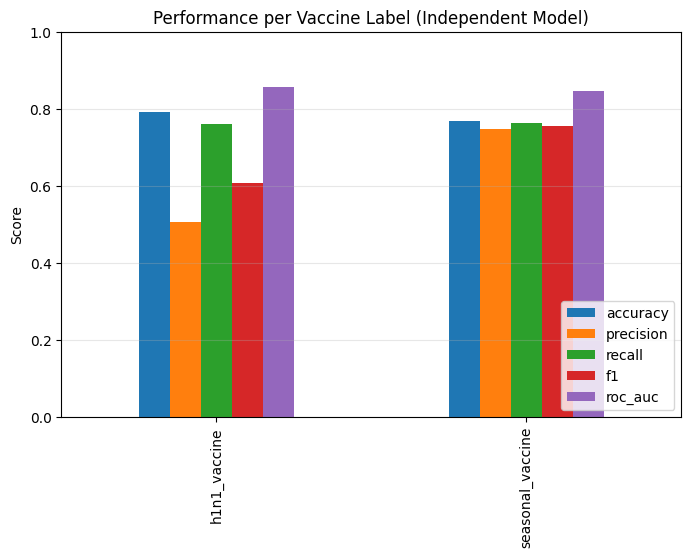

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load stored results
res = results["independent"]["avg"]["per_label"]

# Convert to DataFrame for easy plotting
metrics_df = pd.DataFrame(res).T  # transpose for readability
metrics_df = metrics_df[["accuracy", "precision", "recall", "f1", "roc_auc"]]

print(metrics_df.round(3))

# Plot comparison
metrics_df.plot(kind="bar", figsize=(8, 5))
plt.title("Performance per Vaccine Label (Independent Model)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.grid(axis="y", alpha=0.3)
plt.show()

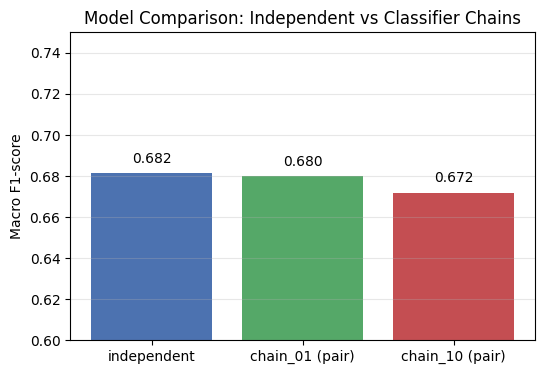

In [ ]:
import matplotlib.pyplot as plt

scores = results["scores_macro_f1"]

plt.figure(figsize=(6,4))
plt.bar(scores.keys(), scores.values(), color=["#4c72b0", "#55a868", "#c44e52"])
plt.ylabel("Macro F1-score")
plt.title("Model Comparison: Independent vs Classifier Chains")
plt.ylim(0.6, 0.75)
plt.grid(axis="y", alpha=0.3)
for k, v in scores.items():
    plt.text(k, v+0.005, f"{v:.3f}", ha='center')
plt.show()


**Key Findings:**

- The **Independent model** achieved the highest macro F1-score (~0.68), slightly outperforming both chain directions.  
  This indicates that the two vaccination outcomes - H1N1 and Seasonal - are only **weakly dependent**, and modeling one as a feature for the other provides little additional benefit.

- **H1N1 prediction** is more challenging:
  - Lower precision (~0.51) suggests many false positives.
  - Higher recall (~0.76) indicates the model captures most true vaccinated individuals but overpredicts uptake.
  - This aligns with the fact that H1N1 vaccination depended more on *perceived risk* and *awareness*, which are harder to infer from survey data.

- **Seasonal vaccine prediction** shows stronger and more balanced performance (F1 ≈ 0.76), reflecting clearer demographic and behavioral patterns (e.g., doctor recommendation, age, health worker status).

**Conclusion:**

The independent approach is both **simpler and more stable**, making it a strong baseline for future modeling.  
The results provide a realistic foundation for the next steps - refining features, testing tree-based models, and analyzing feature importance to uncover actionable insights for:
1. **Public health targeting:** identifying vulnerable, unvaccinated groups.  
2. **Marketing optimization:** focusing outreach on groups with moderate vaccination likelihood.


In [4]:
features = train_X.columns.tolist()
print(features)


['Unnamed: 0', 'respondent_id', 'h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal', 'chronic_med_condition', 'child_under_6_months', 'health_worker', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk', 'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective', 'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'age_group', 'education', 'income_poverty', 'household_adults', 'household_children', 'sex_Male', 'marital_status_Missing', 'marital_status_Not Married', 'rent_or_own_Own', 'rent_or_own_Rent', 'health_insurance_1.0', 'health_insurance_Missing', 'race_Hispanic', 'race_Other or Multiple', 'race_White', 'employment_status_Missing', 'employment_status_Not in Labor Force', 'employment_status_Unemployed', 'census_msa_MSA, Principle City', 'census_msa_Non-MSA', 'hhs_geo_regio